# Indonesian Job Salary Prediction: Text Processing & ML Regression

**Author:** Dimas Raditya Putra Handoko

Raw data only gives `Judul Pekerjaan` (job title), `Perusahaan` (company), and `Lokasi` (location) — no clean, structured features. This notebook engineers `Experience_Level`, `Job_Category`, and a grouped `Lokasi` from the raw title/location text, then trains a Random Forest regressor to predict `Gaji_Rata2` (average salary).

## Step 1: Data Loading

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('job_salary_mean.csv')
print(df.shape)
df.head()

(32976, 4)


,Judul Pekerjaan,Perusahaan,Lokasi,Gaji_Rata2
0,Senior Customer Service,PT Higienis Indonesia,Jakarta Raya,10500000
1,Senior Customer Service,PT Higienis Indonesia,Jakarta Raya,9221095
2,Management Trainee Store Kalimantan,PT Richeese Kuliner Indonesia,Banjarmasin Selatan,5409910
3,Business Development Executive,PT Arupa Cloud Nusantara,Jakarta Selatan,10500000
4,Content Creator,PT. Cahaya Ayu Abadi,Kecamatan Tangerang,6000000


## Step 2: Feature Engineering (the magic sauce)

Two rule-based extractors read keywords out of `Judul Pekerjaan` with `str.contains()`-style logic:
- **`Experience_Level`** — seniority tier (Entry-Level, Staff/Mid-Level, Senior, Supervisor/Lead, Manager, Director/Executive), checked in order from most to least senior so a title matching multiple keywords gets its highest tier.
- **`Job_Category`** — functional area (Sales & Marketing, IT & Digital, Finance & Accounting, etc.), matched against a keyword dictionary.

In [2]:
def get_experience_level(title):
    t = title.lower()
    if any(k in t for k in ['direktur', 'director', 'chief', ' vp ', 'general manager', 'ceo', 'coo', 'cfo']):
        return 'Director/Executive'
    if 'manager' in t or 'manajer' in t:
        return 'Manager'
    if any(k in t for k in ['supervisor', 'spv', 'team leader', 'kepala', 'coordinator', 'koordinator']) or t.startswith('lead'):
        return 'Supervisor/Lead'
    if 'senior' in t or re.search(r'\bsr\b', t):
        return 'Senior'
    if any(k in t for k in ['junior', 'trainee', 'intern', 'magang', 'fresh graduate', 'entry level']):
        return 'Entry-Level'
    return 'Staff/Mid-Level'

CATEGORY_KEYWORDS = {
    'Sales & Marketing': ['sales', 'marketing', 'account', 'b2b', 'business development', 'promoter', 'salesman', 'advisor'],
    'Finance & Accounting': ['finance', 'accounting', 'tax', 'audit', 'treasury', 'akuntan'],
    'HR & GA': [r'\bhr\b', 'hrd', r'\bga\b', 'recruitment'],
    'Customer Service': ['customer service', 'call center', r'\bcs\b', 'response representative'],
    'IT & Digital': [r'\bit\b', 'developer', 'programmer', 'software', r'\bdata\b', 'digital', r'\bweb\b', 'drafter', 'system'],
    'Operations & Logistics': ['admin', 'logistic', 'warehouse', 'supply chain', 'asset', 'operator', 'supir', 'driver', 'surveyor'],
    'Healthcare': ['dokter', 'perawat', 'apoteker', 'farmasi', 'kefarmasian', 'estetika', 'medis'],
    'Production & Quality': ['quality', 'production', 'produksi', 'packaging', 'mining', 'engineer'],
    'Creative & Design': ['content creator', 'design', 'video editor', 'beauty'],
}

def get_job_category(title):
    t = title.lower()
    for cat, keys in CATEGORY_KEYWORDS.items():
        for k in keys:
            match = re.search(k, t) if k.startswith(r'\b') else (k in t)
            if match:
                return cat
    return 'Other'

df['Experience_Level'] = df['Judul Pekerjaan'].apply(get_experience_level)
df['Job_Category'] = df['Judul Pekerjaan'].apply(get_job_category)

df['Experience_Level'].value_counts()

Experience_Level
Staff/Mid-Level       20833
Manager                5518
Supervisor/Lead        5104
Director/Executive      916
Entry-Level             311
Senior                  294
Name: count, dtype: int64

## Step 3: Location Grouping

`Lokasi` has 600+ distinct values. Anything containing "Jakarta" becomes `Jakarta`; everything else becomes `Luar Jakarta`, so the model can learn the Jakarta-vs-rest UMR (minimum wage) gap directly.

In [3]:
df['Lokasi_Grouped'] = np.where(df['Lokasi'].str.lower().str.contains('jakarta'), 'Jakarta', 'Luar Jakarta')
df.groupby('Lokasi_Grouped')['Gaji_Rata2'].mean()

Lokasi_Grouped
Jakarta         8.157865e+06
Luar Jakarta    6.697672e+06
Name: Gaji_Rata2, dtype: float64

## Step 4: Drop Unnecessary Columns & Encoding

`Judul Pekerjaan` and `Perusahaan` are dropped (too high-cardinality, and now redundant with the engineered features). The remaining categoricals are one-hot encoded with `pd.get_dummies()`.

In [4]:
df_model = df.drop(columns=['Judul Pekerjaan', 'Perusahaan', 'Lokasi'])
df_encoded = pd.get_dummies(df_model, columns=['Experience_Level', 'Job_Category', 'Lokasi_Grouped'])
df_encoded.head()

,Gaji_Rata2,Experience_Level_Director/Executive,Experience_Level_Entry-Level,Experience_Level_Manager,Experience_Level_Senior,Experience_Level_Staff/Mid-Level,Experience_Level_Supervisor/Lead,Job_Category_Creative & Design,Job_Category_Customer Service,Job_Category_Finance & Accounting,Job_Category_HR & GA,Job_Category_Healthcare,Job_Category_IT & Digital,Job_Category_Operations & Logistics,Job_Category_Other,Job_Category_Production & Quality,Job_Category_Sales & Marketing,Lokasi_Grouped_Jakarta,Lokasi_Grouped_Luar Jakarta
0,10500000,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False
1,9221095,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False
2,5409910,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
3,10500000,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,True,False
4,6000000,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True


## Step 5: Model Training & Evaluation

In [5]:
X = df_encoded.drop(columns=['Gaji_Rata2'])
y = df_encoded['Gaji_Rata2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: Rp {mae:,.0f}")
print(f"R2:  {r2:.4f}")

MAE: Rp 1,035,518
R2:  0.5307


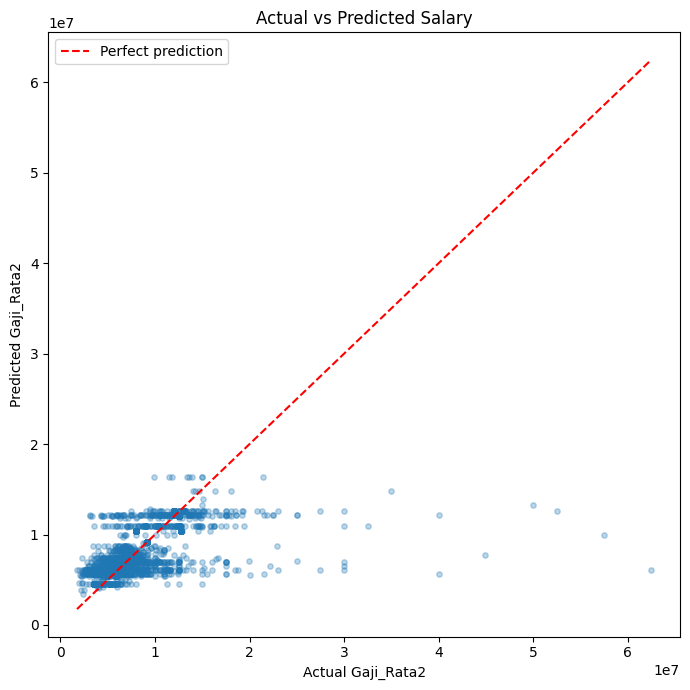

In [6]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=15)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Gaji_Rata2')
plt.ylabel('Predicted Gaji_Rata2')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

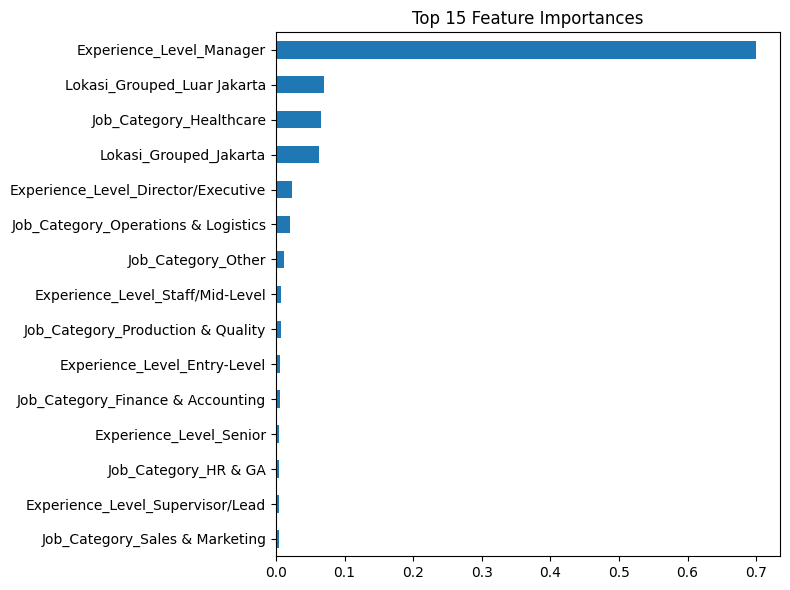

In [7]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()